# 📈 End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Submitted By
**Omprakash Meena**

---

## Project Objective

The objective of this project is to build a complete Sales Forecasting and Demand Intelligence System using historical retail sales data.

The project includes:

- Data Cleaning & Feature Engineering
- Exploratory Data Analysis (EDA)
- Time Series Analysis
- Sales Forecasting using Multiple Models
- Anomaly Detection
- Product Demand Segmentation
- Interactive Streamlit Dashboard
- Executive Business Report

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-Learn
- Statsmodels
- Prophet
- XGBoost
- Streamlit

---

## Dataset

1. Superstore Sales Dataset (`train.csv`)
2. Video Game Sales Dataset (`vgsales.csv`)

In [ ]:
# Installing Required Libraries

%pip install prophet
%pip install xgboost
%pip install statsmodels
%pip install plotly
%pip install streamlit

In [2]:
# Importing Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime

plt.style.use("ggplot")
%matplotlib inline

# Task 1 — Data Loading, Merging & Deep Exploration 

In [3]:
# Loding the datasets

sales_df = pd.read_csv("train.csv")
vg_df = pd.read_csv("vgsales.csv")

In [4]:
print("Superstore Sales Dataset")

print("Shape:", sales_df.shape)

sales_df.head()

Superstore Sales Dataset
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print("Video Game Sales Dataset")
print("Shape",vg_df.shape)

vg_df.head()

Video Game Sales Dataset
Shape (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Data Quality Assessment & Cleaning

In this section, we evaluate the quality of the dataset before performing any analysis.

The following checks are performed:

- Data Types
- Missing Values
- Duplicate Records
- Invalid Entries
- Date Conversion

In [6]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
vg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


In [13]:
# checking for missing values

missing_values = sales_df.isnull().sum()

missing_values[missing_values > 0]

Postal Code    11
dtype: int64

In [16]:
vg_missing = vg_df.isnull().sum()

vg_missing[vg_missing > 0]

Year         271
Publisher     58
dtype: int64

In [10]:
# Cheking duplicate record

print("Sales Dataset Duplicates :", sales_df.duplicated().sum())
print("Video Game Dataset Duplicates :", vg_df.duplicated().sum())

Sales Dataset Duplicates : 0
Video Game Dataset Duplicates : 0


In [11]:
sales_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [12]:
vg_df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [14]:
sales_df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [15]:
vg_df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [20]:
# Converting date columns

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    errors="coerce"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    errors="coerce"
)

print(sales_df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


### Observation

The dataset contains no significant missing values that require treatment.

Therefore, no imputation or removal of records is necessary.

## Feature Engineering

Feature Engineering is the process of creating new, meaningful features from existing data.

For time-series forecasting, extracting temporal information from dates is crucial because machine learning models cannot directly interpret datetime objects.

The following features are created:

- Order Year
- Order Month
- Month Name
- Quarter
- Week Number
- Day of Week
- Day Name
- Season
- Shipping Time (Days)

In [28]:
# reloding the fresh data again

# Reload fresh dataset
sales_df = pd.read_csv("train.csv")

In [32]:
# Converting Date Columns

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

print(sales_df["Order Date"].isna().sum())
print(sales_df["Ship Date"].isna().sum())

0
0


In [35]:
# Date Feature Engineering


sales_df["Order Year"] = sales_df["Order Date"].dt.year

sales_df["Order Month"] = sales_df["Order Date"].dt.month

sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week

sales_df["Day of Week"] = sales_df["Order Date"].dt.dayofweek

sales_df["Day Name"] = sales_df["Order Date"].dt.day_name()

print("Date features created successfully.")

Date features created successfully.


In [36]:
# Season Feature

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8]:
        return "Monsoon"

    else:
        return "Autumn"

sales_df["Season"] = sales_df["Order Month"].apply(get_season)

print("Season feature created.")

Season feature created.


In [37]:
# Shipping Duration

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

print("Shipping Days calculated.")

Shipping Days calculated.


In [38]:
sales_df[
    [
        "Order Date",
        "Ship Date",
        "Order Year",
        "Order Month",
        "Month Name",
        "Quarter",
        "Week Number",
        "Day Name",
        "Season",
        "Shipping Days"
    ]
].head()

,Order Date,Ship Date,Order Year,Order Month,Month Name,Quarter,Week Number,Day Name,Season,Shipping Days
0,2017-11-08,2017-11-11,2017,11,November,4,45,Wednesday,Autumn,3
1,2017-11-08,2017-11-11,2017,11,November,4,45,Wednesday,Autumn,3
2,2017-06-12,2017-06-16,2017,6,June,2,24,Monday,Monsoon,4
3,2016-10-11,2016-10-18,2016,10,October,4,41,Tuesday,Autumn,7
4,2016-10-11,2016-10-18,2016,10,October,4,41,Tuesday,Autumn,7


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the business through data.

This section focuses on identifying sales patterns, customer behavior, regional performance, category contribution, shipping performance, and seasonal trends.

In [39]:
# Dataset Overview

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Total Orders        : {sales_df.shape[0]}")
print(f"Total Features      : {sales_df.shape[1]}")
print(f"Total Sales         : ${sales_df['Sales'].sum():,.2f}")
print(f"Average Sales       : ${sales_df['Sales'].mean():,.2f}")
print(f"Maximum Sale        : ${sales_df['Sales'].max():,.2f}")
print(f"Minimum Sale        : ${sales_df['Sales'].min():,.2f}")

DATASET OVERVIEW
Total Orders        : 9800
Total Features      : 27
Total Sales         : $2,261,536.78
Average Sales       : $230.77
Maximum Sale        : $22,638.48
Minimum Sale        : $0.44


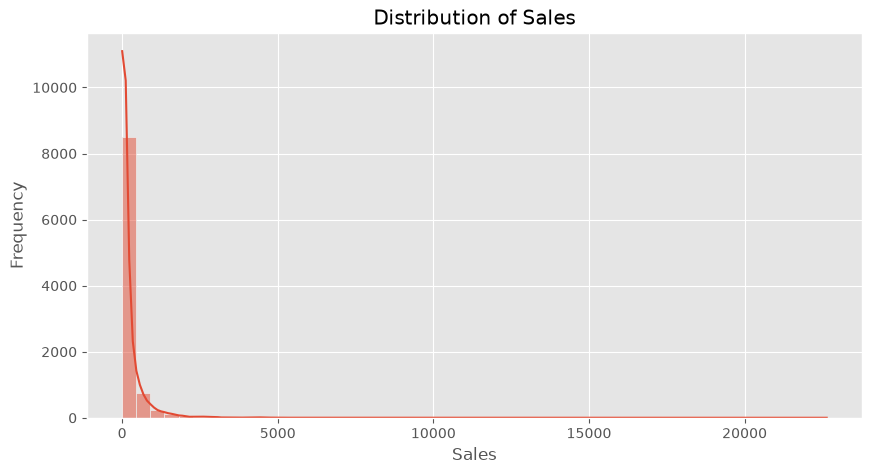

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    sales_df["Sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation

The sales distribution is positively skewed.

Most transactions involve relatively small sales amounts, while a few orders contribute exceptionally high sales values.

## Q.1 Total Revenue by Category

In [41]:
category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

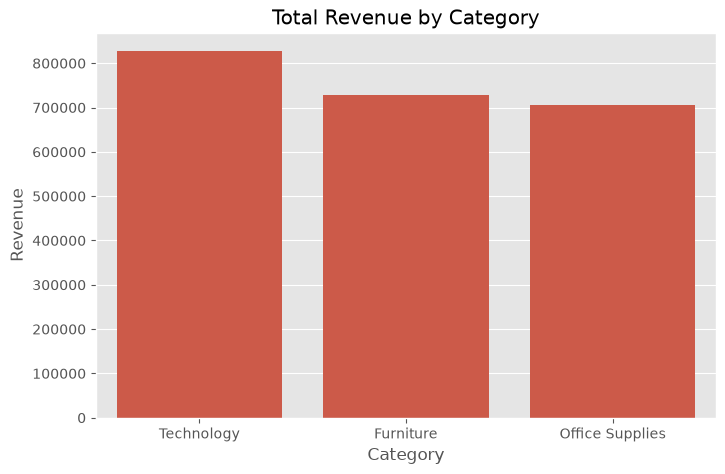

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

### Observation

The category with the highest total revenue is "Technology", from the visualization above.

This category contributes the largest share of total business revenue and should be prioritized in future demand forecasting and inventory planning.

## Q.2 Sales by Region

In [43]:
region_sales = (
    sales_df
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

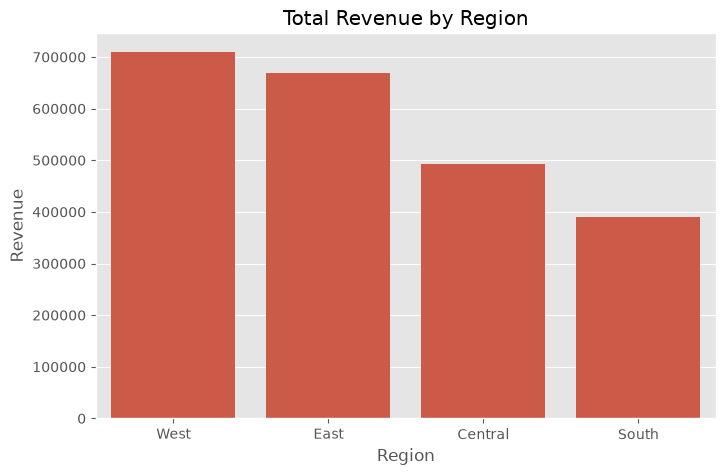

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

### Observation

The visualization highlights the contribution of each region toward total sales.

Regions with higher revenue indicate stronger market demand and greater business opportunities.

## Q.3 Sales by Segment

In [45]:
segment_sales = (
    sales_df
    .groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

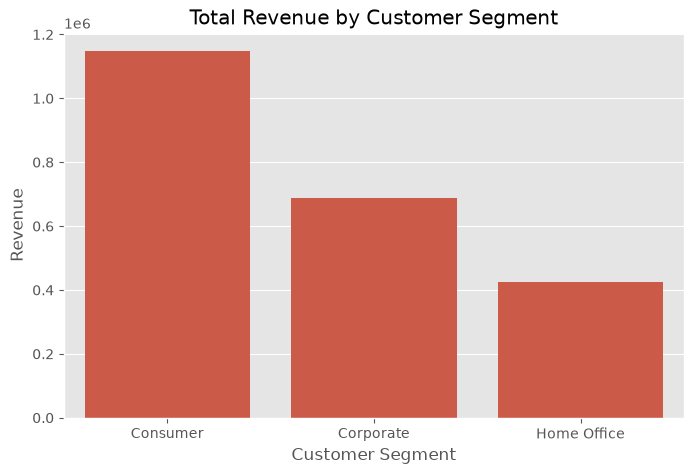

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Revenue by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Revenue")

plt.show()

### Observation

Different customer segments contribute differently to total sales.

Understanding segment-wise revenue helps businesses prioritize marketing and customer retention strategies.

## Q.4 Top 10 States by Sales

In [47]:
top_states = (
    sales_df
    .groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

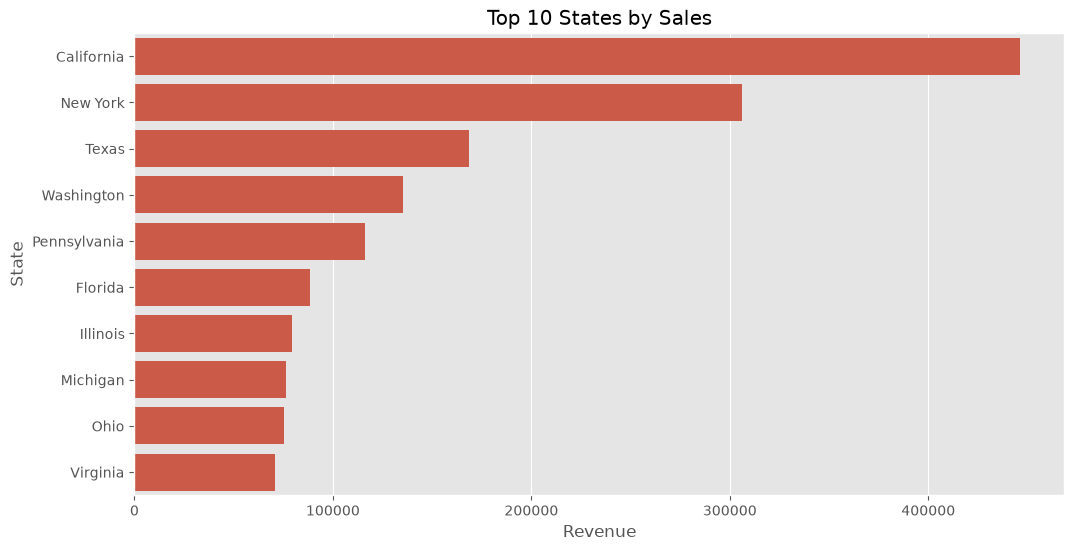

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")

plt.xlabel("Revenue")

plt.ylabel("State")

plt.show()

### Observation

The top-performing states generate a significant proportion of overall sales.

These regions represent high-value markets and deserve focused inventory and business expansion strategies.

## Business Insights & Time-Based Analysis

In this section, we answer key business questions using aggregated sales data and time-based analysis.

The objective is to identify sales growth patterns, shipping efficiency, and seasonality.

### Daily, Weekly & Monthly Sales Aggregation

In [49]:
daily_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [50]:
weekly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [52]:
monthly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

The sales data has been aggregated into daily, weekly, and monthly levels.

These aggregated datasets will be used for time series decomposition, forecasting models, and anomaly detection in the subsequent tasks.

## Monthly Sales Trend

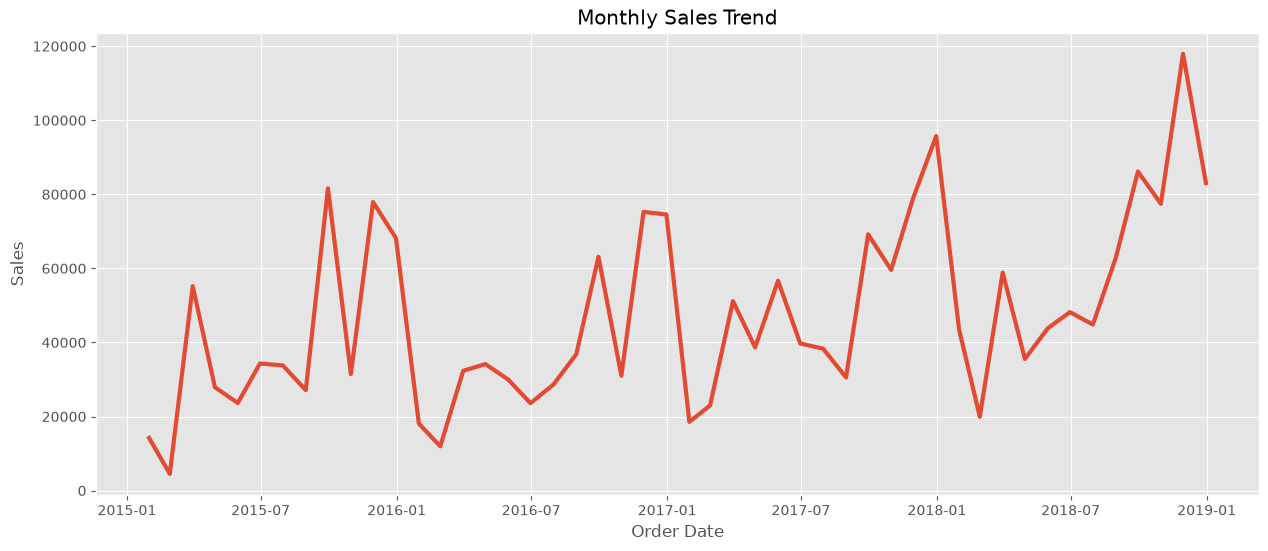

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=3
)

plt.title("Monthly Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend indicates fluctuations in revenue over time, suggesting the presence of both long-term trends and seasonal effects.

These patterns will be further analyzed using time series decomposition in Task 2.

## Revenue by Year

In [54]:
yearly_sales = (
    sales_df
    .groupby("Order Year")["Sales"]
    .sum()
)

yearly_sales

Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

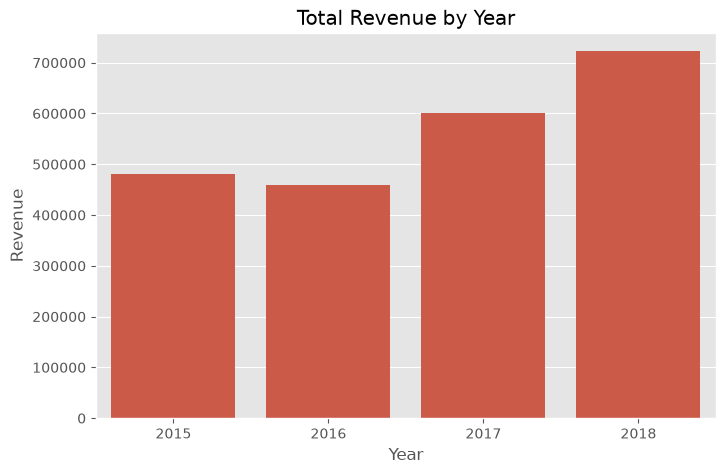

In [55]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Total Revenue by Year")

plt.xlabel("Year")

plt.ylabel("Revenue")

plt.show()

## Revenue by Month

In [56]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = (
    sales_df
    .groupby("Month Name")["Sales"]
    .sum()
    .reindex(month_order)
)

monthly_revenue

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

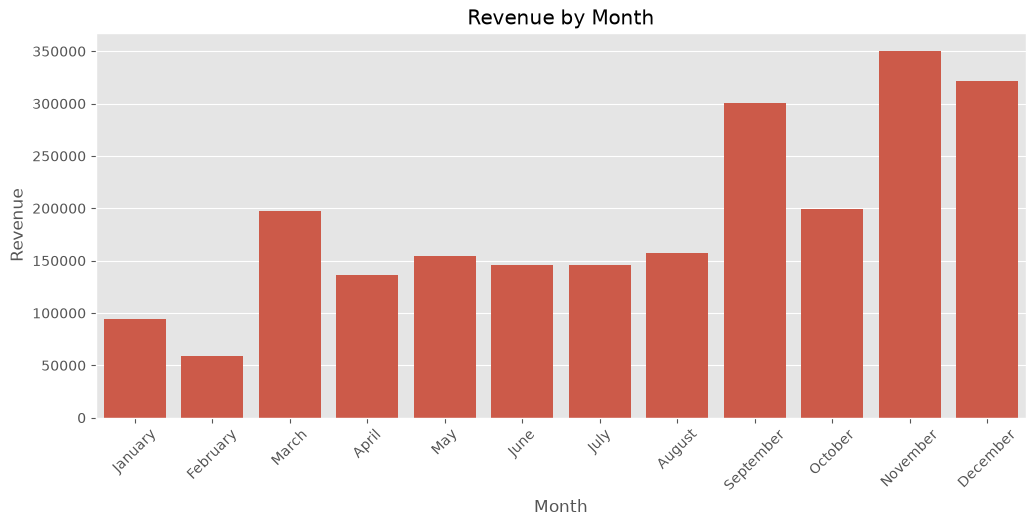

In [57]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Month")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

### Observation

The monthly revenue chart highlights recurring high-sales and low-sales months.

This provides initial evidence of seasonal demand patterns that can improve forecasting accuracy.

## Average Shipping Time by Region

In [58]:
shipping_region = (
    sales_df
    .groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

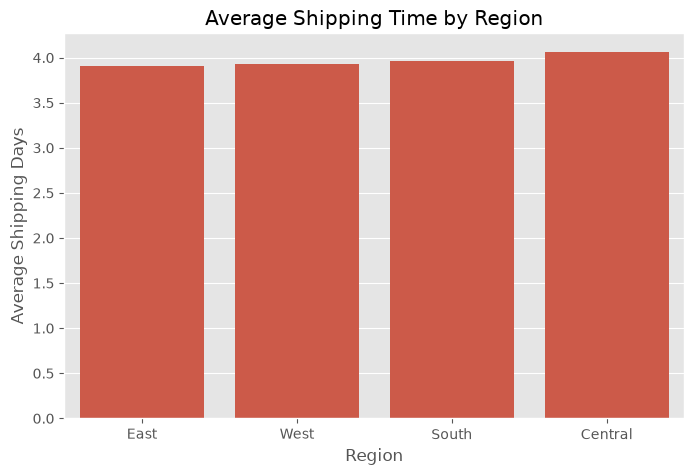

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Shipping Days")

plt.show()

### Observation

The chart compares average shipping duration across regions.

Regions with longer delivery times may indicate opportunities for logistics optimization and supply chain improvements.

### Which Category Generates the Highest Revenue?

In [60]:
highest_category = category_sales.idxmax()

highest_sales = category_sales.max()

print("Highest Revenue Category :", highest_category)

print(f"Revenue : ${highest_sales:,.2f}")

Highest Revenue Category : Technology
Revenue : $827,455.87


### Which Region Has the Highest Revenue?

In [61]:
highest_region = region_sales.idxmax()

highest_region_sales = region_sales.max()

print("Highest Revenue Region :", highest_region)

print(f"Revenue : ${highest_region_sales:,.2f}")

Highest Revenue Region : West
Revenue : $710,219.68


### Average Shipping Time

In [62]:
print(
    "Average Shipping Time :",
    round(sales_df["Shipping Days"].mean(),2),
    "days"
)

Average Shipping Time : 3.96 days


## Which region has the most consistent sales growth over 4 years?

In [63]:
region_year_sales = (
    sales_df
    .groupby(["Order Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

region_year_sales.head()

,Order Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


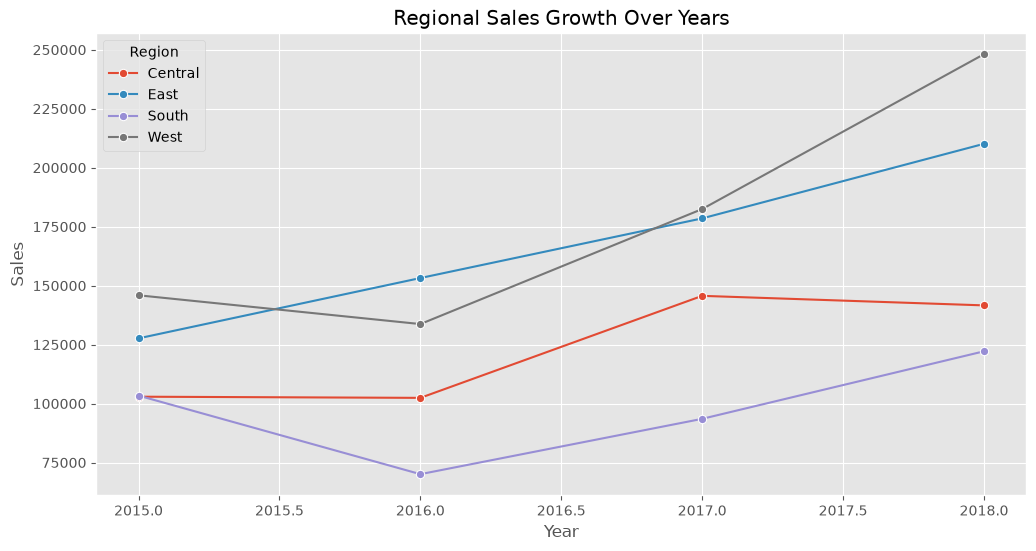

In [64]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year_sales,
    x="Order Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth Over Years")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

### Observation

The regional sales trend over multiple years helps identify which region demonstrates the most stable and consistent growth.

This insight is valuable for long-term inventory planning and strategic market expansion.

## Task 1 Completed